#mount google drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


#Load Data

In [ ]:
import os
import librosa
import numpy as np

# Define paths
base_path = "/content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/"

# Label map
label_map = {
    'Female_dysarthria': 1,
    'Male_dysarthria': 1,
    'Female_Non_Dysarthria': 0,
    'Male_Non_Dysarthria': 0
}

# Feature extraction
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.mean(mfccs.T, axis=0)

# Load data
X = []
y = []

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    label = label_map.get(folder)

    if label is not None:
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            try:
                features = extract_features(file_path)
                X.append(features)
                y.append(label)
            except Exception as e:
                print(f"Error with {file_path}: {e}")

X = np.array(X)
y = np.array(y)


<ipython-input-2-e55cada73d62>:18: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=3, offset=0.5)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error with /content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Female_Non_Dysarthria/FC01: [Errno 21] Is a directory: '/content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Female_Non_Dysarthria/FC01'
Error with /content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Female_Non_Dysarthria/FC03: [Errno 21] Is a directory: '/content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Female_Non_Dysarthria/FC03'
Error with /content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Male_Non_Dysarthria/MC01: [Errno 21] Is a directory: '/content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Male_Non_Dysarthria/MC01'
Error with /content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Male_Non_Dysarthria/MC02: [Errno 21] Is a directory: '/content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Male_Non_Dysarthria/MC02'
Error with /content/drive/MyDrive/DataSets/Dysarthria and Non Dysart

In [ ]:
import os

base_path = "/content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/"
print("Folders found:", os.listdir(base_path))


Folders found: ['Female_Non_Dysarthria', 'Male_Non_Dysarthria', 'Male_Dysarthria', 'Female_dysarthria']


In [ ]:
sample_folder = os.path.join(base_path, "Female_dysarthria")
print("Files in Female_dysarthria:", os.listdir(sample_folder)[:5])


Files in Female_dysarthria: ['F01', 'F03', 'F04']


In [ ]:
import os
import librosa
import numpy as np

base_path = "/content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/"

label_map = {
    'Female_dysarthria': 1,
    'Male_dysarthria': 1,
    'Female_Non_Dysarthria': 0,
    'Male_Non_Dysarthria': 0
}

def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.mean(mfccs.T, axis=0)

X = []
y = []

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    label = label_map.get(folder)

    if label is not None:
        for root, dirs, files in os.walk(folder_path):  # 👈 recursively go through subfolders
            for file in files:
                if file.endswith('.wav'):
                    file_path = os.path.join(root, file)
                    try:
                        features = extract_features(file_path)
                        X.append(features)
                        y.append(label)
                    except Exception as e:
                        print(f"❌ Failed to process {file_path}: {e}")

X = np.array(X)
y = np.array(y)

print(f"✅ Total samples loaded: {len(X)}")


<ipython-input-5-824863d59a56>:15: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=3, offset=0.5)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(


❌ Failed to process /content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Female_dysarthria/F01/Session1/Wav/0067.wav: 
❌ Failed to process /content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Female_dysarthria/F01/Session1/Wav/0068.wav: 


/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=663
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1898
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=984
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=975
  warnings.warn(


✅ Total samples loaded: 3660


#🧪 Step 1: Train-test split



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


#🧠 Step 2: Build a Neural Network (TensorFlow/Keras)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(40,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')  # 2 classes: dysarthria or non-dysarthria
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#⚙️ Step 3: Compile the model




In [ ]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


#🏋️ Step 4: Train the model



In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.7149 - loss: 7.3519 - val_accuracy: 0.8320 - val_loss: 0.5893
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7835 - loss: 1.2349 - val_accuracy: 0.8511 - val_loss: 0.4308
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8005 - loss: 0.6223 - val_accuracy: 0.8265 - val_loss: 0.4120
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8286 - loss: 0.4224 - val_accuracy: 0.8607 - val_loss: 0.3588
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8261 - loss: 0.4127 - val_accuracy: 0.9126 - val_loss: 0.3927
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8498 - loss: 0.3807 - val_accuracy: 0.9030 - val_loss: 0.2896
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8862 - loss: 0.3025 - val_accuracy: 0.9249 - val_loss: 0.2934
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8727 - loss: 0.3170 - val_accuracy: 0.9249 - val_loss

#📊 Step 5: Evaluate the model

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9857 - loss: 0.1501 
Test Accuracy: 98.77%


#📈Step 6: Plot training performance

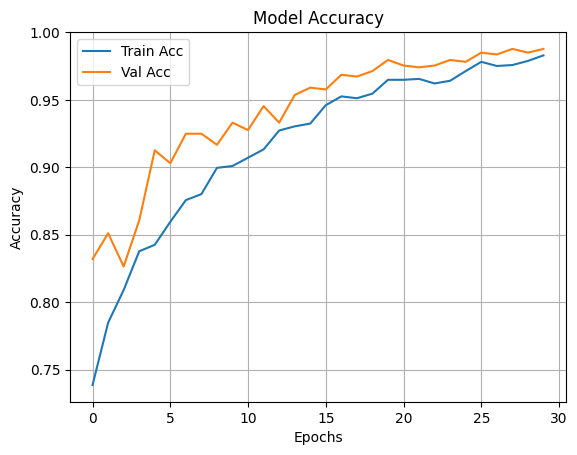

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


#💾 Step 6: Save the model


In [ ]:
model.save('/content/drive/MyDrive/dysarthria_model.h5')


##🚀 1. Converting My Model to TensorFlow Lite (TFLite)

In [ ]:
import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model('/content/drive/MyDrive/dysarthria_model.h5')

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model
with open('/content/drive/MyDrive/dysarthria_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Model converted to TFLite!")


Saved artifact at '/tmp/tmp5df3soqh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  138205404985488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138205404986448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138205404987216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138205270656784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138205270656016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138205270657936: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Model converted to TFLite!


In [ ]:
import numpy as np
import librosa

# Load and preprocess audio
file_path = '/content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Female_Non_Dysarthria/FC01/Session1/Wav/0001.wav'
y, sr = librosa.load(file_path, sr=16000)  # Match training sample rate
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
mfcc = mfcc.T  # Shape: (time_steps, 13)

# Resize/pad/truncate to expected input shape (e.g., (X, 13))
# Assume the model expects input shape (X, 13); adjust if needed
desired_shape = (50, 13)  # Example
if mfcc.shape[0] < desired_shape[0]:
    # Pad with zeros
    pad_width = desired_shape[0] - mfcc.shape[0]
    mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), mode='constant')
else:
    # Truncate
    mfcc = mfcc[:desired_shape[0], :]

# Final reshape (add batch dimension)
input_data = np.expand_dims(mfcc, axis=0).astype(np.float32)


In [ ]:
import tensorflow as tf

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path="/content/drive/MyDrive/dysarthria_model.tflite")
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Set input tensor
interpreter.set_tensor(input_details[0]['index'], input_data)

# Run inference
interpreter.invoke()

# Get output
output_data = interpreter.get_tensor(output_details[0]['index'])
print("Prediction:", output_data)


Prediction: [[0.99188995 0.00811   ]]


In [ ]:
input_details = interpreter.get_input_details()
print("Expected input shape:", input_details[0]['shape'])


Expected input shape: [ 1 40]


In [ ]:
import numpy as np
import librosa

# Load audio
file_path = '/content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Female_Non_Dysarthria/FC01/Session1/Wav/0001.wav'
y, sr = librosa.load(file_path, sr=16000)

# Extract 40 MFCCs (to match expected input)
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

# Average across time axis to reduce shape from (40, T) -> (40,)
mfcc_mean = np.mean(mfcc, axis=1)

# Reshape to match model input shape [1, 40]
input_data = np.expand_dims(mfcc_mean, axis=0).astype(np.float32)


In [ ]:
import tensorflow as tf

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/content/drive/MyDrive/dysarthria_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Set input and run inference
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Get prediction
output_data = interpreter.get_tensor(output_details[0]['index'])
print("Raw output:", output_data)

# If it's a classification model
predicted_class = np.argmax(output_data)
print("Predicted class:", predicted_class)


Raw output: [[0.99188995 0.00811   ]]
Predicted class: 0


In [ ]:
import librosa
import numpy as np
import tensorflow as tf

def preprocess_audio(file_path):
    # Load audio
    y, sr = librosa.load(file_path, sr=16000, duration=3, offset=0.5)

    # Extract MFCCs (40 coefficients as trained)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

    # Average across time
    mfcc_mean = np.mean(mfcc, axis=1)

    # Reshape for model input (1, 40)
    return np.expand_dims(mfcc_mean, axis=0).astype(np.float32)

# Test prediction
def predict(file_path):
    # Load TFLite model
    interpreter = tf.lite.Interpreter(model_path="/content/drive/MyDrive/dysarthria_model.tflite")
    interpreter.allocate_tensors()

    # Preprocess audio
    input_data = preprocess_audio(file_path)

    # Run inference
    interpreter.set_tensor(interpreter.get_input_details()[0]['index'], input_data)
    interpreter.invoke()

    # Get output
    output = interpreter.get_tensor(interpreter.get_output_details()[0]['index'])
    return output[0]  # Returns [non-dysarthria_prob, dysarthria_prob]

# Example usage - Replace with path to an actual audio file
# prediction = predict("test_audio.wav") # This line is incorrect!
prediction = predict('/content/drive/MyDrive/DataSets/Dysarthria and Non Dysarthria/Dataset/Female_Non_Dysarthria/FC01/Session1/Wav/0001.wav')  # Use a valid path
print(f"Probabilities: {prediction}")
print(f"Predicted class: {np.argmax(prediction)} (0=Non-dysarthria, 1=Dysarthria)")

Probabilities: [9.993043e-01 6.957527e-04]
Predicted class: 0 (0=Non-dysarthria, 1=Dysarthria)
